# 沐曦 GPU 运行 VoxelMorph 说明文档
## VoxelMorph 简介
[VoxelMorph](https://github.com/voxelmorph/voxelmorph) 是一个面向学习型图像对齐与配准的通用开源库，也支持更广义的形变建模。在医学图像配准中，模型以固定图像（fixed）和待配准图像（moving）为输入，学习空间变换或稠密位移场，并将 moving 图像映射到 fixed 的坐标空间。典型的无监督训练结合图像相似性损失与形变平滑正则项，不需要预先提供逐体素的真实形变场。

本教程聚焦其中的图像配准流程：先用合成二维图像从头演示 PyTorch 无监督训练，再调用官方预训练 [SynthMorph](https://synthmorph.io/) affine 模型完成 CT 到 T1 加权 MRI 的推理。SynthMorph 利用合成图像训练，面向不同图像对比度下的配准；二维 demo 仅用于展示训练流程，并非 SynthMorph 权重训练或临床验证。

VoxelMorph 由上游作者以 Apache-2.0 许可证发布，我方未修改其源代码。您可通过[项目主页](https://github.com/voxelmorph/voxelmorph)、[许可证](https://github.com/voxelmorph/voxelmorph/blob/master/LICENSE.md)和本目录的 [LICENSE](./LICENSE) 查阅源代码、版权与归属声明及其他项目文档。示例输入来自上游公开 SynthMorph 资源；再分发前请分别核对其数据和模型权利。

本文档仅用于开源软件配置和工程验证，不构成诊断、治疗或临床性能结论。

## 1. 安装
### 1.1 环境准备
使用沐曦开发者社区的 [Docker 镜像资源中心](https://developer.metax-tech.com/softnova/docker/) 获取 MACA PyTorch 镜像。下面的命令使用已验证的 Python 3.10/MACA PyTorch 镜像；如需其他版本，请同步调整依赖和python版本。

```bash
docker run -it --name voxelmorph-maca-torch \
  --device=/dev/mxcd --group-add video \
  --shm-size=16G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /workspace:/workspace \
  harbor.sh.mxcr.io/public-library/maca-pytorch:3.8.2.6-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```
**参数说明：**
- `--device=/dev/mxcd`：挂载沐曦计算设备。
- `--group-add video`：允许容器访问 GPU 设备。
- `--shm-size=16G`：为数据处理和模型运行提供共享内存。
- `-v /workspace:/workspace`：挂载 Notebook 和运行目录。
### 1.2 安装依赖
容器内使用镜像提供的 MACA PyTorch：

```bash
python -m pip install packaging scikit-image h5py nibabel scipy matplotlib tqdm scikit-learn
NEURITE_COMMIT=9ae2f5cec2201eedbcc6929cecf852193cef7646
python -m pip install --no-deps "https://github.com/adalca/neurite/archive/${NEURITE_COMMIT}.zip"
VXM_COMMIT=53d1b95fa734648c92fd8af4f3807b09cb56c342
python -m pip install --no-deps "https://github.com/voxelmorph/voxelmorph/archive/${VXM_COMMIT}.zip"
python -m pip install surfa pystrum
python -c "import torch; assert torch.cuda.is_available(); print(torch.__version__, torch.cuda.get_device_name(0))"
```

PyTorch 任务使用 `torch.device('cuda:0')`；在 MACA 版 PyTorch 中该 CUDA API 是设备兼容层。示例默认 `VOXELMORPH_IMAGE_SIZE=128`，可设置为 `256` 以使用更大的二维图像。

官方 `mri_synthmorph` 使用 TensorFlow 和 `.h5` 权重。TensorFlow/MACA 软件包和兼容镜像请通过沐曦开发者社区的 [Docker 镜像资源中心](https://developer.metax-tech.com/softnova/docker/) 获取对应对版本。Torch 和 TensorFlow 安装在同一个 Python 环境中，使用正常的包安装方式。VoxelMorph 提供 PyTorch 与 TensorFlow 两种实现，运行时由 backend 环境变量选择对应 API。

下面命令从获取的MACA TensorFlow 归档中安装 wheel 到当前 `/opt/conda` 环境：

```bash
export TF_ARCHIVE=/workspace/maca_archives/maca-tensorflow2-2.13.1-py310-3.8.0.10-linux-x86_64.tar.xz
TF_PREFIX=/workspace/voxelmorph_demo/maca_tf_3.8.0.10
mkdir -p "${TF_PREFIX}"
tar -xJf "${TF_ARCHIVE}" -C "${TF_PREFIX}" --strip-components=1
python -m pip install --no-index "${TF_PREFIX}"/tensorflow-2.13.1+maca3.8.0.10-cp310-cp310-linux_x86_64.whl
python -m pip install surfa nibabel pystrum scikit-image matplotlib
# Torch 2.6 需要较新的 typing-extensions；安装 TensorFlow 后恢复该运行时依赖。
python -m pip install "typing-extensions>=4.10"
python -c "import torch, tensorflow as tf; print(torch.__version__, tf.__version__, tf.config.list_physical_devices('GPU'))"
```

Torch、MACA TensorFlow 及两种 VoxelMorph backend 安装在同一个 `/opt/conda` 环境中；TensorFlow 2.13 的旧版依赖元数据可能产生提示，但应以 Torch/TensorFlow 导入和 GPU 探针结果为准。下面的 PyTorch demo training 固定至少运行 3 个 epoch；TensorFlow 部分对应官方 SynthMorph 推理，不伪造额外训练结果。

```bash
export VOXELMORPH_WORKDIR=/workspace/voxelmorph_demo
export FREESURFER_SYNTHMORPH_COMMIT=9f23ef349976e3b455778f865bceed24d79aa89d
mkdir -p ${VOXELMORPH_WORKDIR}/mri_synthmorph/synthmorph ${VOXELMORPH_WORKDIR}/mri_synthmorph/models
url=https://raw.githubusercontent.com/freesurfer/freesurfer/${FREESURFER_SYNTHMORPH_COMMIT}/mri_synthmorph
wget -q -O ${VOXELMORPH_WORKDIR}/mri_synthmorph/mri_synthmorph ${url}/mri_synthmorph
wget -q -O ${VOXELMORPH_WORKDIR}/mri_synthmorph/synthmorph/registration.py ${url}/synthmorph/registration.py
wget -q -O ${VOXELMORPH_WORKDIR}/mri_synthmorph/synthmorph/utils.py ${url}/synthmorph/utils.py
wget -q -O ${VOXELMORPH_WORKDIR}/mri_synthmorph/ct.nii.gz https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/images/ct.nii.gz
wget -q -O ${VOXELMORPH_WORKDIR}/mri_synthmorph/t1.nii.gz https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/images/t1.nii.gz
wget -q -O ${VOXELMORPH_WORKDIR}/mri_synthmorph/models/synthmorph.affine.2.h5 https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/synthmorph.affine.2.h5
chmod +x ${VOXELMORPH_WORKDIR}/mri_synthmorph/mri_synthmorph
```

CT 和 T1 示例由 FreeSurfer SynthMorph 公开文档提供；请在再分发输入、模型权重或生成结果前复核上游数据和模型许可。

## 2. 环境验证与 PyTorch 运行效果

In [1]:
# 运行参数、输出路径和设备锚点。后续代码均从这里派生。
import os
from pathlib import Path

ROOT = Path(os.environ.get('VOXELMORPH_WORKDIR', '/workspace/voxelmorph_demo'))
TRAIN_DIR = ROOT / 'torch_demo_training'
TORCH_WEIGHTS = TRAIN_DIR / 'vxm_dense_demo.pt'
IMAGE_SIZE = int(os.environ.get('VOXELMORPH_IMAGE_SIZE', '128'))
NUM_LABELS = 16
NUM_MAPS = 40
TRAIN_EPOCHS = max(3, int(os.environ.get('VOXELMORPH_TRAIN_EPOCHS', '3')))
STEPS_PER_EPOCH = int(os.environ.get('VOXELMORPH_STEPS_PER_EPOCH', '100'))
DEVICE = 'cuda:0'
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
os.environ['VXM_BACKEND'] = 'pytorch'
os.environ['NEURITE_BACKEND'] = 'pytorch'
import torch
if not torch.cuda.is_available():
    raise RuntimeError('未检测到 MACA PyTorch GPU；请确认容器映射 /dev/mxcd 且使用 MACA PyTorch 镜像。')
print('PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0))
print('device:', DEVICE, 'image shape:', (IMAGE_SIZE, IMAGE_SIZE))
print('training:', TRAIN_EPOCHS, 'epochs x', STEPS_PER_EPOCH, 'steps/epoch (minimum 3 epochs)')
print('weights:', TORCH_WEIGHTS)

PyTorch: 2.6.0+metax3.8.2.2
GPU: MetaX C500
device: cuda:0 image shape: (64, 64)
training: 3 epochs x 2 steps/epoch (minimum 3 epochs)
weights: /workspace/voxelmorph_demo/torch_demo_training/vxm_dense_demo.pt


label maps: (40, 64, 64) uint8


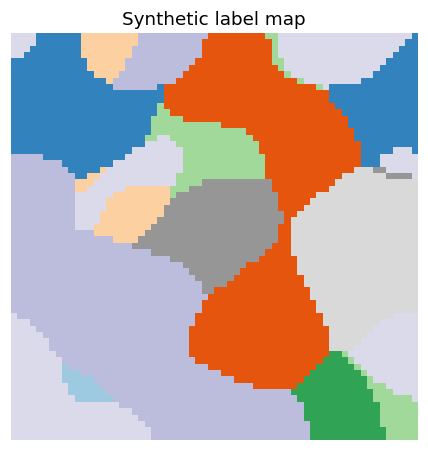

In [2]:
# 生成合成标签图和随机强度对比度图像。
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(2026)
label_maps = []
for _ in range(NUM_MAPS):
    fields = np.stack([gaussian_filter(rng.normal(size=(IMAGE_SIZE, IMAGE_SIZE)), sigma=rng.uniform(5, 18)) for _ in range(NUM_LABELS)], axis=0)
    label_maps.append(np.argmax(fields, axis=0).astype(np.uint8))
label_maps = np.stack(label_maps)

def labels_to_image(labels, local_rng):
    lut = local_rng.uniform(0.05, 0.95, size=NUM_LABELS).astype(np.float32)
    image = lut[labels] + local_rng.normal(0, 0.03, labels.shape).astype(np.float32)
    image -= image.min()
    return image / max(float(image.max()), np.finfo(np.float32).eps)

def batch_generator():
    while True:
        indices = rng.integers(0, NUM_MAPS, size=2)
        source = labels_to_image(label_maps[indices[0]], rng)
        target = labels_to_image(label_maps[indices[1]], rng)
        yield (torch.from_numpy(source[None, None]), torch.from_numpy(target[None, None]))

print('label maps:', label_maps.shape, label_maps.dtype)
plt.imshow(label_maps[0], cmap='tab20c'); plt.title('Synthetic label map'); plt.axis('off'); plt.show()

In [3]:
# 构造 PyTorch VoxelMorph 模型和无监督损失。
import os
os.environ['VXM_BACKEND'] = 'pytorch'
os.environ['NEURITE_BACKEND'] = 'pytorch'
import warnings
warnings.filterwarnings('ignore', message='torch.meshgrid')
import torch.nn as nn
import voxelmorph as vxm

model = vxm.torch.networks.VxmDense(
    inshape=(IMAGE_SIZE, IMAGE_SIZE),
    nb_unet_features=[[16, 16, 16], [16, 16, 16, 16]],
    int_steps=5, int_downsize=1,
).to(DEVICE)
image_loss = nn.MSELoss()
gradient_loss = vxm.torch.losses.Grad(penalty='l2')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
train_iter = iter(batch_generator())
print('model:', type(model).__name__, 'parameters:', sum(p.numel() for p in model.parameters()))

model: VxmDense parameters: 21426


epoch 1/3: loss=0.174633
epoch 2/3: loss=0.161780
epoch 3/3: loss=0.123032
saved Torch weights: /workspace/voxelmorph_demo/torch_demo_training/vxm_dense_demo.pt


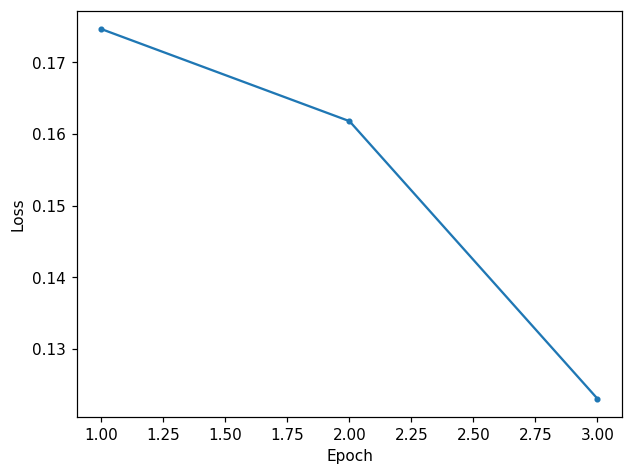

In [4]:
# 执行 PyTorch demo training。
loss_history = []
model.train()
for epoch in range(TRAIN_EPOCHS):
    running = 0.0
    for _ in range(STEPS_PER_EPOCH):
        source, target = (x.to(DEVICE) for x in next(train_iter))
        optimizer.zero_grad(set_to_none=True)
        warped_source, displacement = model(source, target)
        loss = image_loss(warped_source, target) + 0.05 * gradient_loss.loss(None, displacement)
        loss.backward()
        optimizer.step()
        running += float(loss.detach().cpu())
    epoch_loss = running / STEPS_PER_EPOCH
    loss_history.append(epoch_loss)
    print(f'epoch {epoch + 1}/{TRAIN_EPOCHS}: loss={epoch_loss:.6f}')
torch.save({'model_state_dict': model.state_dict(), 'image_size': IMAGE_SIZE}, TORCH_WEIGHTS)
print('saved Torch weights:', TORCH_WEIGHTS)
plt.plot(range(1, len(loss_history) + 1), loss_history, '.-'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

source/target/moved: torch.Size([1, 1, 64, 64]) torch.Size([1, 1, 64, 64]) (64, 64)
displacement: (1, 2, 64, 64) finite: True


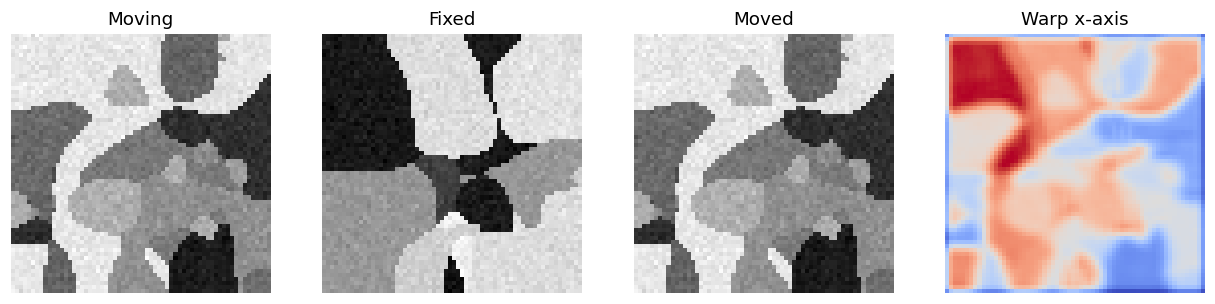

In [5]:
# 在保留的合成图像对上执行 PyTorch 推理。
model.eval()
with torch.no_grad():
    source_np = labels_to_image(label_maps[1], rng)
    target_np = labels_to_image(label_maps[7], rng)
    source = torch.from_numpy(source_np[None, None]).to(DEVICE)
    target = torch.from_numpy(target_np[None, None]).to(DEVICE)
    warped, displacement = model(source, target)
moved_np = warped[0, 0].float().cpu().numpy()
field_np = displacement[0].float().cpu().numpy()
print('source/target/moved:', source.shape, target.shape, moved_np.shape)
print('displacement:', tuple(displacement.shape), 'finite:', bool(torch.isfinite(displacement).all()))
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, image, title in zip(axes, (source_np, target_np, moved_np, field_np[0]), ('Moving', 'Fixed', 'Moved', 'Warp x-axis')):
    ax.imshow(image, cmap='gray' if title != 'Warp x-axis' else 'coolwarm'); ax.set_title(title); ax.axis('off')
plt.show()

## 3. 官方 `mri_synthmorph` 运行效果

`mri_synthmorph` 是 FreeSurfer 发布的 TensorFlow CLI。下面的代码使用同一 `sys.executable` 调用已正常安装的 TensorFlow、Neurite 和 VoxelMorph 包，并加载官方 `.h5` 权重。

准备好公开示例输入和模型权重后，执行官方 affine 命令。`-g` 使用 MACA GPU，`-e 192` 设置注册空间范围：

```bash
cd /workspace/voxelmorph_demo/mri_synthmorph
./mri_synthmorph register -g -e 192 -m affine \
  -w models/synthmorph.affine.2.h5 \
  -t outputs/ct_to_t1.lta -o outputs/ct_moved_to_t1.nii.gz \
  outputs/ct_clipped_0_80.nii.gz t1.nii.gz
```


python: /opt/conda/bin/python
command: /opt/conda/bin/python /workspace/voxelmorph_demo/mri_synthmorph/mri_synthmorph register -g -e 192 -m affine -w /workspace/voxelmorph_demo/mri_synthmorph/models/synthmorph.affine.2.h5 -t /workspace/voxelmorph_demo/mri_synthmorph/outputs/ct_to_t1.lta -o /workspace/voxelmorph_demo/mri_synthmorph/outputs/ct_moved_to_t1.nii.gz /workspace/voxelmorph_demo/mri_synthmorph/outputs/ct_clipped_0_80.nii.gz /workspace/voxelmorph_demo/mri_synthmorph/t1.nii.gz
#@# mri_synthmorph: affine, threads: None, VmPeak: 128063252
Thank you for choosing SynthMorph. Please cite us!

SynthMorph: learning contrast-invariant registration without acquired images
Hoffmann M, Billot B, Greve DN, Iglesias JE, Fischl B, Dalca AV
IEEE Transactions on Medical Imaging, 41 (3), 543-558, 2022
https://doi.org/10.1109/TMI.2021.3116879

Anatomy-specific acquisition-agnostic affine registration learned from
fictitious images
Hoffmann M, Hoopes A, Fischl B*, Dalca AV* (*equal contribution)
SP

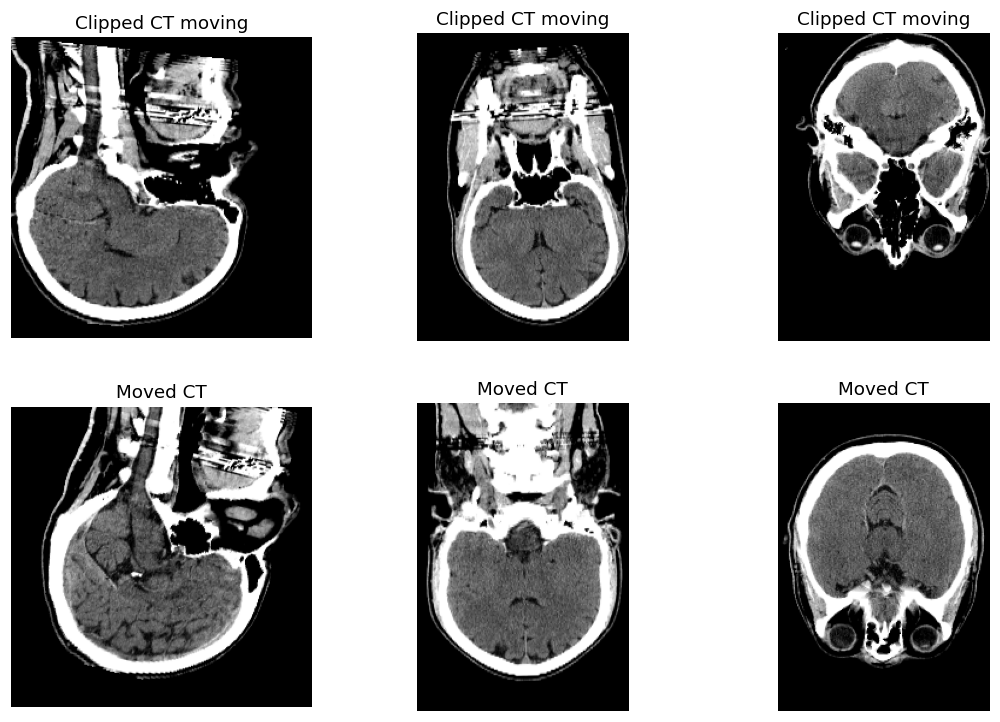

In [6]:
# 在同一 Python 环境中调用上游 TensorFlow CLI。
import os
import sys
import subprocess
SM_DIR = ROOT / 'mri_synthmorph'
SM_SCRIPT = SM_DIR / 'mri_synthmorph'
SM_ASSETS = (SM_SCRIPT, SM_DIR / 'ct.nii.gz', SM_DIR / 't1.nii.gz', SM_DIR / 'models' / 'synthmorph.affine.2.h5')
missing = [str(path) for path in SM_ASSETS if not path.exists()]
if missing:
    raise FileNotFoundError('mri_synthmorph assets not prepared: ' + ', '.join(missing))
import surfa as sf
OUTPUT_DIR = SM_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ct = sf.load_volume(str(SM_DIR / 'ct.nii.gz'))
t1 = sf.load_volume(str(SM_DIR / 't1.nii.gz'))
clipped = OUTPUT_DIR / 'ct_clipped_0_80.nii.gz'
moved = OUTPUT_DIR / 'ct_moved_to_t1.nii.gz'
transform = OUTPUT_DIR / 'ct_to_t1.lta'
ct.clip(0, 80).save(str(clipped))
cmd = [sys.executable, str(SM_SCRIPT), 'register', '-g', '-e', '192', '-m', 'affine', '-w', str(SM_DIR / 'models' / 'synthmorph.affine.2.h5'), '-t', str(transform), '-o', str(moved), str(clipped), str(SM_DIR / 't1.nii.gz')]
child_env = {**os.environ, 'NEURITE_BACKEND': 'tensorflow', 'VXM_BACKEND': 'tensorflow'}
proc = subprocess.run(cmd, cwd=str(SM_DIR), env=child_env, text=True, capture_output=True)
print('python:', sys.executable)
print('command:', ' '.join(cmd))
print(proc.stdout)
if proc.returncode:
    print(proc.stderr)
    raise RuntimeError(f'mri_synthmorph failed with exit code {proc.returncode}')
print('moved CT:', moved)
print('LTA transform:', transform)
moved_volume = sf.load_volume(str(moved)).resample_like(t1)
# Use the same clipped moving image for the pre/post comparison.
ct_volume = sf.load_volume(str(clipped)).resample_like(t1)
def unit_norm(volume):
    data = np.asarray(volume.data, dtype=np.float32)
    data -= data.min()
    return data / max(float(data.max()), np.finfo(np.float32).eps)
before = unit_norm(ct_volume) - unit_norm(t1)
after = unit_norm(moved_volume) - unit_norm(t1)
mid = tuple(size // 2 for size in after.shape)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, (volume, title) in enumerate(((ct_volume, 'Clipped CT moving'), (moved_volume, 'Moved CT'))):
    data = unit_norm(volume)
    for col, slc in enumerate((data[mid[0], :, :], data[:, mid[1], :], data[:, :, mid[2]])):
        axes[row, col].imshow(slc.T, cmap='gray'); axes[row, col].set_title(title); axes[row, col].axis('off')
plt.show()
print('fixed/moved shape:', t1.shape, moved_volume.shape)
print('finite moved output:', bool(np.isfinite(moved_volume.data).all()))
print('difference RMS before/after (same clipped CT, T1 grid):', float(np.sqrt(np.mean(before ** 2))), float(np.sqrt(np.mean(after ** 2))))

---

本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.